<a href="https://colab.research.google.com/github/milanjob755/AIDI1002W2026/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report

from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from google.colab import files

uploaded = files.upload()


Saving assignment1_dataset.xlsx to assignment1_dataset.xlsx


In [17]:
# STEP 1: Load dataset

df = pd.read_excel("assignment1_dataset.xlsx")

df.head()

,EmployeeID,Gender,Age,WorkHours,SleepHours,AttendanceRate,PreviousPerformance,EducationLevel,RemoteWork,ProductivityScore
0,E001,Male,29,8,7,92,78,Bachelor,Yes,82
1,E002,Female,34,9,6,88,85,Master,No,87
2,E003,Male,41,10,5,95,90,PhD,No,92
3,E004,Female,26,7,8,85,72,Bachelor,Yes,79
4,E005,Male,38,9,6,90,88,Master,Yes,86


In [18]:
# STEP 2: Create PerformanceCategory for classification

def categorize_performance(score):
    if score > 85:
        return "High Performer"
    elif score >= 70:
        return "Average"
    else:
        return "Low"

df["PerformanceCategory"] = df["ProductivityScore"].apply(categorize_performance)

# Check results
df[["ProductivityScore", "PerformanceCategory"]].head()

,ProductivityScore,PerformanceCategory
0,82,Average
1,87,High Performer
2,92,High Performer
3,79,Average
4,86,High Performer


In [19]:
# STEP 3: Prepare features and targets

# Regression target
y_reg = df["ProductivityScore"]

# Classification target
y_class = df["PerformanceCategory"]

# Features
X = df.drop(["EmployeeID", "ProductivityScore", "PerformanceCategory"], axis=1)

# Convert categorical variables to numeric
X = pd.get_dummies(X, drop_first=True)

# Check features
X.head()


,Age,WorkHours,SleepHours,AttendanceRate,PreviousPerformance,Gender_Male,EducationLevel_Bachelor,EducationLevel_Master,EducationLevel_PhD,RemoteWork_Yes
0,29,8,7,92,78,True,True,False,False,True
1,34,9,6,88,85,False,False,True,False,False
2,41,10,5,95,90,True,False,False,True,False
3,26,7,8,85,72,False,True,False,False,True
4,38,9,6,90,88,True,False,True,False,True


In [20]:
# STEP 4: Train-Test Split

from sklearn.model_selection import train_test_split

# Split for regression
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Split for classification
_, _, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training feature shape: (16, 10)
Testing feature shape: (4, 10)


In [21]:
# STEP 5: Linear Regression Model

from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()

# Train the model
reg_model.fit(X_train, y_train_reg)

print("Regression model trained successfully")

Regression model trained successfully


In [22]:
# STEP 6: Make predictions and evaluate regression model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions
y_pred = reg_model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test_reg, y_pred)
mse = mean_squared_error(y_test_reg, y_pred)
r2 = r2_score(y_test_reg, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 1.435997232312733
Mean Squared Error: 2.6515031524324137
R2 Score: 0.9091562089102385


In [23]:
# STEP 7: Classification Model

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

# Train classifier
clf.fit(X_train, y_train_class)

print("Classification model trained successfully")

Classification model trained successfully


In [24]:
# STEP 8: Evaluate classification model

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Make predictions
y_pred_class = clf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test_class, y_pred_class)

print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_class)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test_class, y_pred_class))

Accuracy: 0.75
Confusion Matrix:
 [[3 0]
 [1 0]]

Classification Report:

                precision    recall  f1-score   support

       Average       0.75      1.00      0.86         3
High Performer       0.00      0.00      0.00         1

      accuracy                           0.75         4
     macro avg       0.38      0.50      0.43         4
  weighted avg       0.56      0.75      0.64         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
# STEP 9: Prepare features for clustering

from sklearn.preprocessing import StandardScaler

cluster_features = df[["WorkHours","SleepHours","AttendanceRate","ProductivityScore"]]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

print("Features prepared for clustering")

Features prepared for clustering


In [26]:
# STEP 10: Apply KMeans clustering

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

df["Cluster"] = clusters

df[["WorkHours","SleepHours","AttendanceRate","ProductivityScore","Cluster"]].head()

,WorkHours,SleepHours,AttendanceRate,ProductivityScore,Cluster
0,8,7,92,82,2
1,9,6,88,87,1
2,10,5,95,92,1
3,7,8,85,79,0
4,9,6,90,86,1


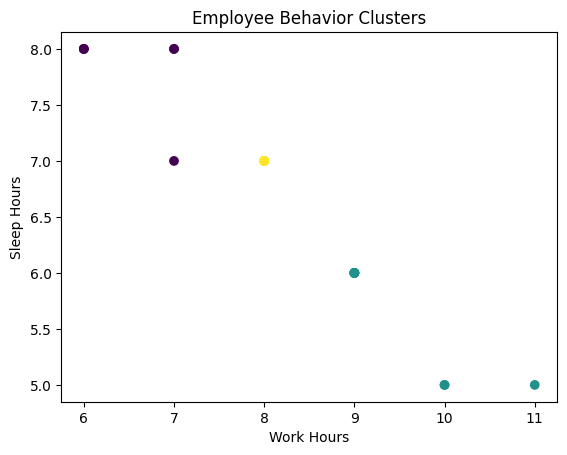

In [27]:
# STEP 11: Cluster visualization

import matplotlib.pyplot as plt

plt.scatter(df["WorkHours"], df["SleepHours"], c=df["Cluster"])

plt.xlabel("Work Hours")
plt.ylabel("Sleep Hours")
plt.title("Employee Behavior Clusters")

plt.show()

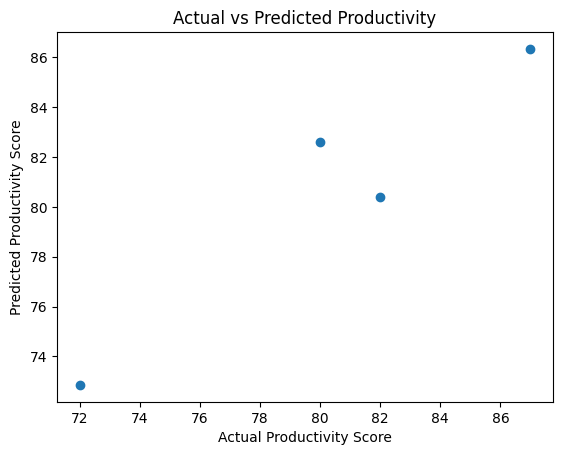

In [28]:
# STEP 12: Actual vs Predicted visualization

plt.scatter(y_test_reg, y_pred)

plt.xlabel("Actual Productivity Score")
plt.ylabel("Predicted Productivity Score")
plt.title("Actual vs Predicted Productivity")

plt.show()

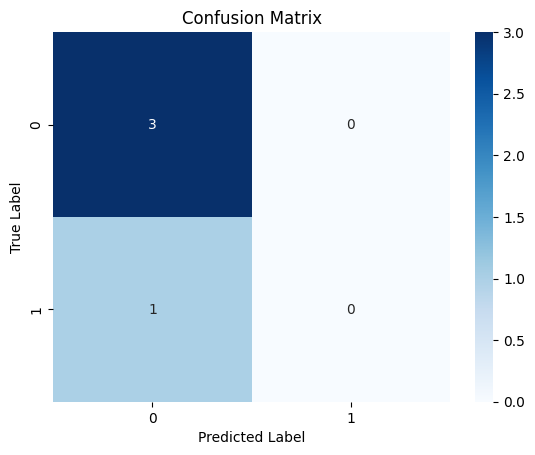

In [29]:
# STEP 13: Confusion Matrix Heatmap

import seaborn as sns

cm = confusion_matrix(y_test_class, y_pred_class)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
# Employee productivity is strongly influenced by factors such as previous performance, attendance rate, and
# work hours. The regression model performed well, achieving an R² score of approximately 0.91, indicating
# that the model explains about 91% of the variance in employee productivity scores. The classification model
# achieved an accuracy of 75%, correctly identifying most employees in the Average performance category,
# although the small dataset limited prediction of High Performers. The clustering analysis grouped employees
# into three behavioral segments based on work hours, sleep hours, attendance, and productivity, revealing
# patterns in work habits and productivity levels. In this project, supervised learning was used to predict
# productivity and classify performance using labeled data, while unsupervised learning
# identified natural groupings in employee behavior without predefined labels.

# From the charts and heatmaps generated in the analysis, we can observe several patterns about employee
# productivity. From the Actual vs Predicted regression plot, we can see that most of the predicted
# productivity scores are close to the actual values, which indicates that the regression model is performing
# well. This is also supported by the high R² score of around 0.91, meaning that the selected features explain a
# large portion of the variation in employee productivity.